In [72]:
using Integrals
using Plots

In [73]:
#using QuadGK
#f(x) = abs(x - 0.3)^(-1 / 4)
#val = quadgk(f, 0, 0.3, 1)

In [74]:
#using Integrals
#f(u, p) = sum(sin.(u))
#domain = (ones(3), 3ones(3)) # (lb, ub)
#prob = IntegralProblem(f, domain)
#sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)
#sol.u

In [75]:
#P(Hi, Hc) = π * Hiσ * Hcσ * exp(-Hi * Hi / Hiσ / Hiσ / 2) * exp(-Hc * Hc / Hcσ / Hcσ / 2) / 2
#Hi = (Ha + Hb) / sqrt(2);
#Hc = (Ha - Hb - 2 * H0) / sqrt(2);

#P(Ha, Hb) = π * Hiσ * Hcσ * exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / 2

In [76]:
Hiσ = 0.3
Hcσ = 0.4
H0 = 1.5;

In [77]:
if false
    P(Ha, Hb) = π * Hiσ * Hcσ * exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / 2
    Haarr = range( 0.0, 3.0, length=100)
    Hbarr = range(-3.0, 0.0, length=100)
    Marr = [P(Ha, Hb) for Ha in Haarr, Hb in Hbarr]
    heatmap(Haarr, Hbarr, Marr, color=:viridis)
end

In [78]:
function Preisach(vars, params=[])
    u, v = vars
    H, Hmax = params
    if H < Hmax
        Ha = u
        Hb = H + (u-H)*(v-H)/(Hmax-H)
        #exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / (2.0 * π * Hiσ * Hcσ)
        return (u-H)/(Hmax-H) * exp(-(Ha + Hb) * (Ha + Hb) / Hiσ / Hiσ / 4) * exp(-(Ha - Hb - 2 * H0) * (Ha - Hb - 2 * H0) / Hcσ / Hcσ / 4) / (2.0 * π * Hiσ * Hcσ)
    else
        return 0
    end
end

Preisach (generic function with 2 methods)

In [79]:
Hmax = 3.0
H = -0.3
domain = ([ H, H ], [ Hmax, Hmax ]) # (lo, up)
params = [H, Hmax]
prob = IntegralProblem(Preisach, domain, params)
sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)

retcode: Success
u: 0.0006724079824207639

In [80]:
H = -Hmax
domain = ([H, H], [Hmax, Hmax]) # (lo, up)
params = [H, Hmax]
prob = IntegralProblem(Preisach, domain, params)
sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)
Ms = first(sol)

0.999988058190527

In [81]:
Npct = 100
Hvals = zeros(Npct)
Mvals = zeros(Npct)
for (i, Happl) in enumerate(reverse(range(-Hmax, Hmax, length=Npct)))
    if Happl == Hmax
        Mvals[i] = 1.0
        Hvals[i] = Hmax
        continue
    end
    domain = ([Happl, Happl], [Hmax, Hmax]) # (lo, up)
    params = [Happl, Hmax]
    prob = IntegralProblem(Preisach, domain, params)
    sol = solve(prob, HCubatureJL(); reltol=1e-3, abstol=1e-3)
    Mvals[i] = 1.0 - 2.0 * first(sol)
    Hvals[i] = Happl
end

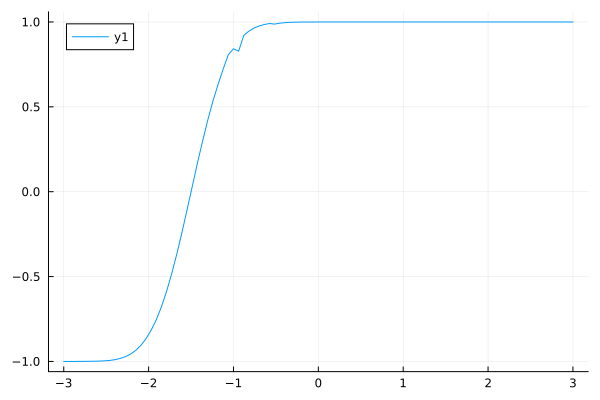

In [82]:
plot(Hvals, Mvals)